#### Dependencies & Setup

In [9]:
# Install dependencies if needed:
# pip install google-cloud-bigquery pandas matplotlib db-dtypes

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Authenticate using your Google Cloud credentials.
# For local development, set:
# export GOOGLE_APPLICATION_CREDENTIALS="/path/to/service-account-key.json"

client = bigquery.Client(project="project-7781a5d3-3f4e-4cd5-a43")

#### 1. Plot Monthly Sales Amount and Number of Orders

/Users/redalpha04/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


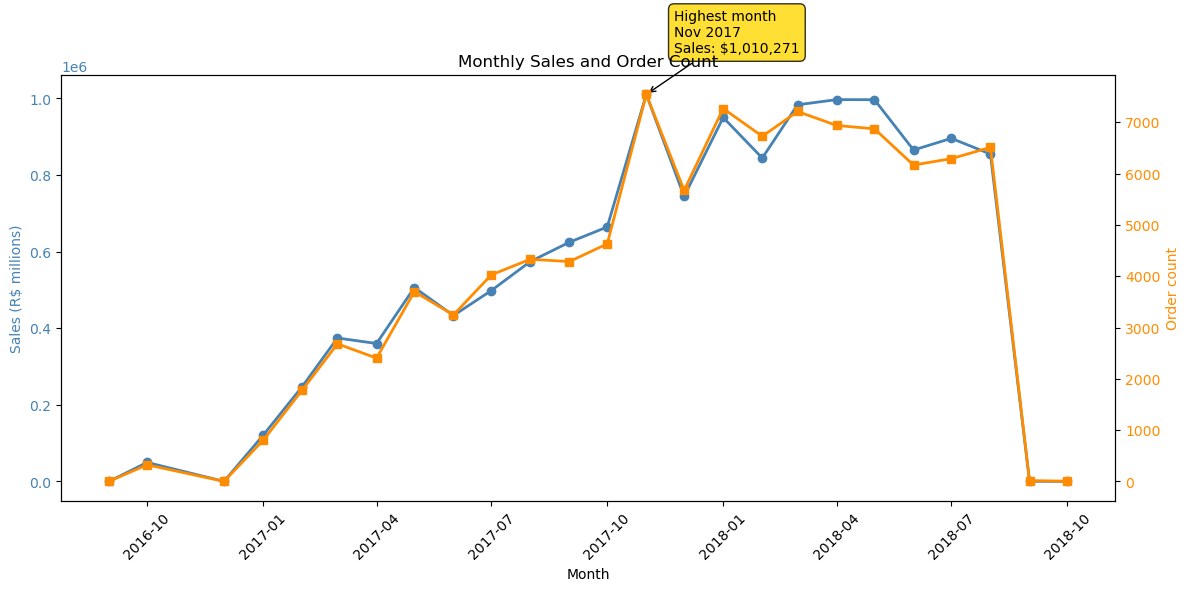

In [15]:
query = """
    SELECT
        month_start_date,
        sales,
        order_count
    FROM `project-7781a5d3-3f4e-4cd5-a43.olist_dev_datamart.mart_monthly_sales`
    ORDER BY month_start_date
"""
monthly_sales = client.query(query).to_dataframe()

# Ensure the date column is correctly typed
monthly_sales["month_start_date"] = pd.to_datetime(
    monthly_sales["month_start_date"]
)

highlight_month = pd.Timestamp("2017-11-01")

# Plot sales and order count
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    monthly_sales["month_start_date"],
    monthly_sales["sales"],
    marker="o",
    color="steelblue",
    linewidth=2,
    label="Sales"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Sales (R$ millions)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.tick_params(axis="x", rotation=45)

# Use a second axis because sales and order_count may have different scales
ax2 = ax1.twinx()

ax2.plot(
    monthly_sales["month_start_date"],
    monthly_sales["order_count"],
    marker="s",
    color="darkorange",
    linewidth=2,
    label="Order count"
)

ax2.set_ylabel("Order count", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

row = monthly_sales[
    monthly_sales["month_start_date"] == highlight_month
].iloc[0]

ax1.annotate(
    f"Highest month\nNov 2017\nSales: ${row['sales']:,.0f}",
    xy=(highlight_month, row["sales"]),
    xytext=(20, 30),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->"},
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "gold",
        "alpha": 0.8
    }
)

plt.title("Monthly Sales and Order Count")
fig.tight_layout()
plt.show()


#### 2. Plot Days to Deliver vs Reviews

In [5]:
query = """
SELECT
    order_id,
    days_to_deliver,
    review_score
FROM `project-7781a5d3-3f4e-4cd5-a43.olist_dev_datamart.mart_delivery_vs_reviews`
WHERE days_to_deliver >= 0
  AND review_score IS NOT NULL
"""

df = client.query(query).to_dataframe()

df["days_to_deliver"] = pd.to_numeric(df["days_to_deliver"])
df["review_score"] = pd.to_numeric(df["review_score"])

# Group by review score
summary = (
    df.groupby("review_score", as_index=False)
      .agg(
          average_days_to_deliver=("days_to_deliver", "mean"),
          median_days_to_deliver=("days_to_deliver", "median"),
          order_count=("order_id", "nunique")
      )
      .sort_values("review_score")
)
print(summary)

/Users/redalpha04/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


   review_score  average_days_to_deliver  median_days_to_deliver  order_count
0             1                20.859694                    16.0         9351
1             2                16.177679                    13.0         2921
2             3                13.789919                    12.0         7916
3             4                11.841645                    10.0        18888
4             5                10.216342                     9.0        56748


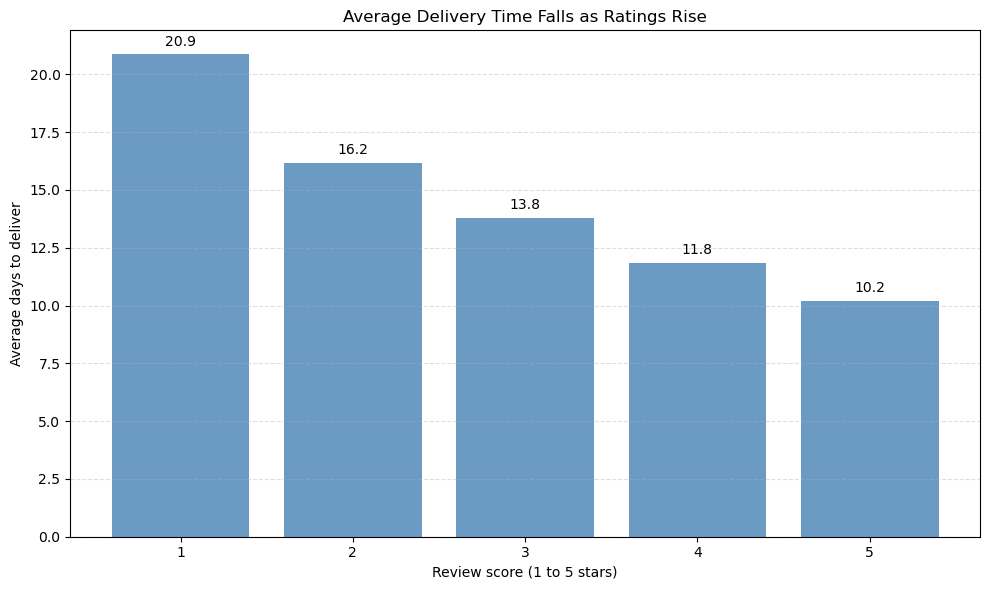

In [12]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Average delivery time
bars = ax1.bar(
    summary["review_score"].astype(str),
    summary["average_days_to_deliver"],
    color="steelblue",
    alpha=0.8
)

ax1.set_xlabel("Review score (1 to 5 stars)")
ax1.set_ylabel("Average days to deliver")
ax1.set_title("Average Delivery Time Falls as Ratings Rise")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# Add values above the bars
for bar in bars:
    height = bar.get_height()
    ax1.annotate(
        f"{height:.1f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


#### 3. Plot top categories

/Users/redalpha04/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


The top 18 categories accounted for 81.3% of total revenue.


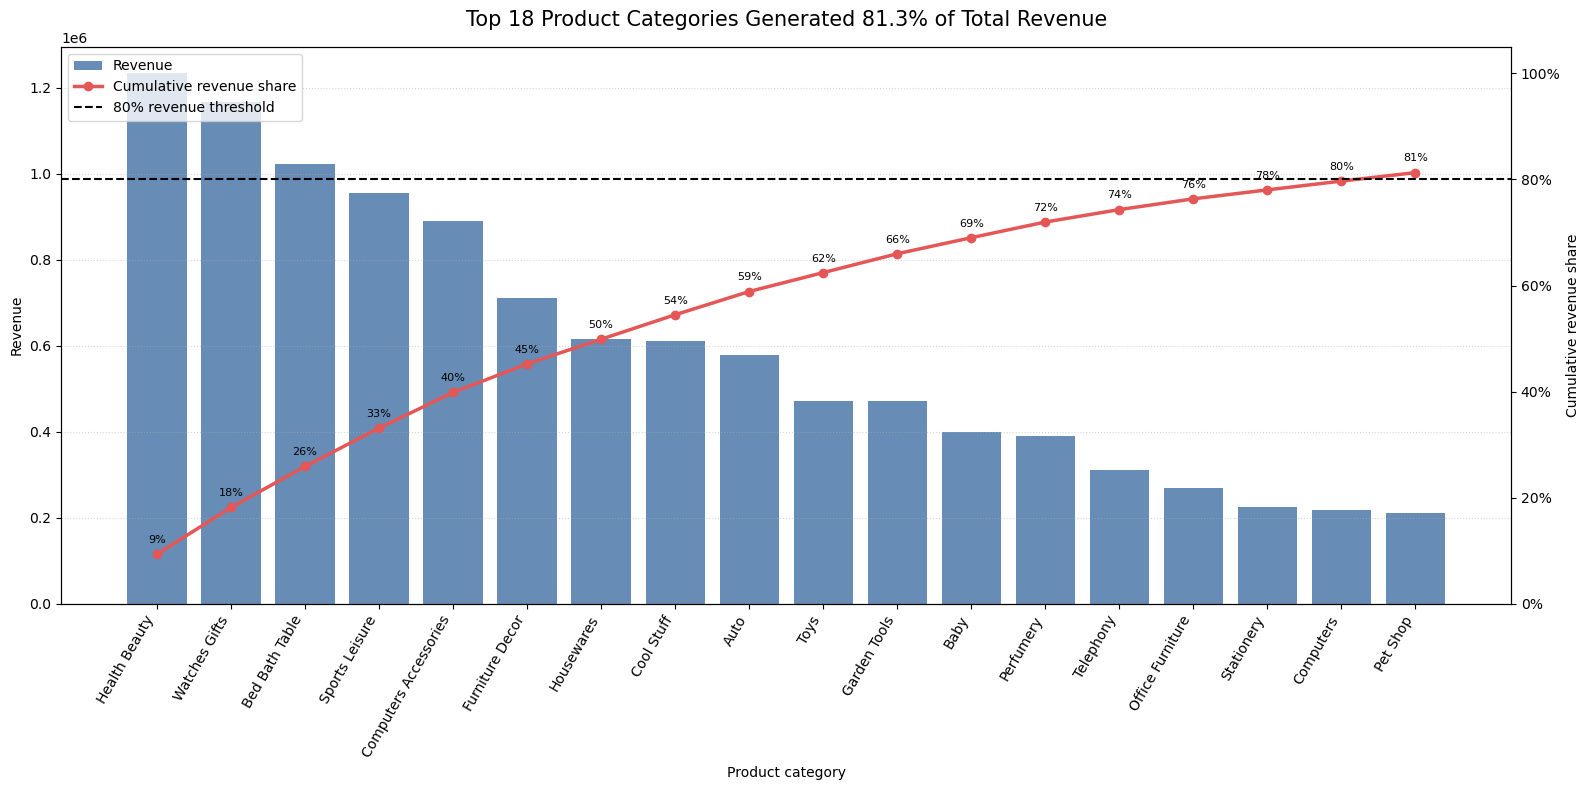

In [10]:
# Query category sales and calculate cumulative revenue share
query = f"""
WITH ranked_sales AS (
    SELECT
        product_category_name,
        sales,
        SUM(sales) OVER () AS total_sales,
        SUM(sales) OVER (
            ORDER BY sales DESC
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS cumulative_sales
    FROM `project-7781a5d3-3f4e-4cd5-a43.olist_dev_datamart.mart_category_sales`
)

SELECT
    product_category_name,
    sales,
    SAFE_DIVIDE(sales, total_sales) AS revenue_share,
    SAFE_DIVIDE(cumulative_sales, total_sales) AS cumulative_revenue_share
FROM ranked_sales
ORDER BY sales DESC
"""

# Load the query result into a DataFrame
sales_by_category = client.query(query).to_dataframe()

# Select the top 18 categories
top_n = 18
top_18 = sales_by_category.head(top_n).copy()

# Calculate the total revenue share of the top 18 categories
top_18_share = top_18["sales"].sum() / sales_by_category["sales"].sum()

print(
    f"The top {top_n} categories accounted for "
    f"{top_18_share:.1%} of total revenue."
)

# Create readable category labels
top_18["category_label"] = (
    top_18["product_category_name"]
    .fillna("Unknown")
    .str.replace("_", " ", regex=False)
    .str.title()
)

# Create the chart
fig, ax1 = plt.subplots(figsize=(16, 8))

x = range(len(top_18))

# Revenue bars
ax1.bar(
    x,
    top_18["sales"],
    color="#4C78A8",
    alpha=0.85,
    label="Revenue"
)

ax1.set_xlabel("Product category")
ax1.set_ylabel("Revenue")
ax1.set_xticks(list(x))
ax1.set_xticklabels(
    top_18["category_label"],
    rotation=60,
    ha="right"
)

# Cumulative revenue line
ax2 = ax1.twinx()

ax2.plot(
    x,
    top_18["cumulative_revenue_share"],
    color="#E45756",
    marker="o",
    linewidth=2.5,
    label="Cumulative revenue share"
)

# 80% reference line
ax2.axhline(
    0.80,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="80% revenue threshold"
)

ax2.set_ylabel("Cumulative revenue share")
ax2.set_ylim(0, 1.05)
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))

# Add percentage labels to the cumulative line
for i, value in enumerate(top_18["cumulative_revenue_share"]):
    ax2.annotate(
        f"{value:.0%}",
        xy=(i, value),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

# Chart title
ax1.set_title(
    f"Top {top_n} Product Categories Generated "
    f"{top_18_share:.1%} of Total Revenue",
    fontsize=15,
    pad=15
)

# Combine legends from both axes
handles_1, labels_1 = ax1.get_legend_handles_labels()
handles_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles_1 + handles_2,
    labels_1 + labels_2,
    loc="upper left"
)

ax1.grid(
    axis="y",
    linestyle=":",
    alpha=0.5
)

plt.tight_layout()
plt.show()
